## Step 4A: K-Means Clustering

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Window

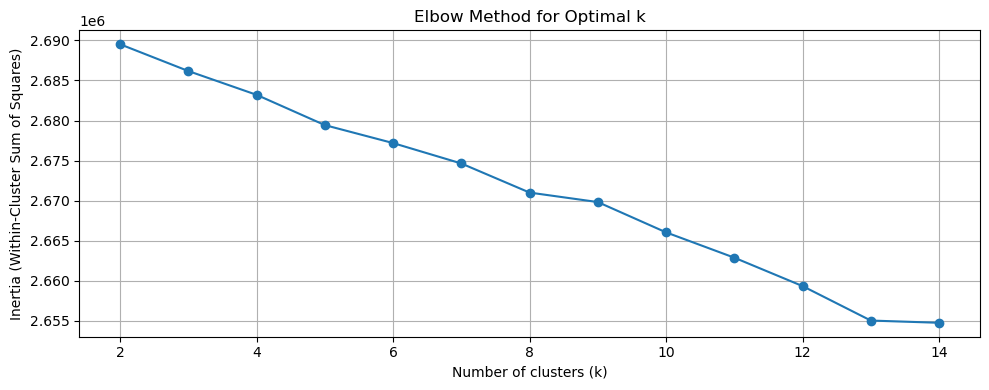

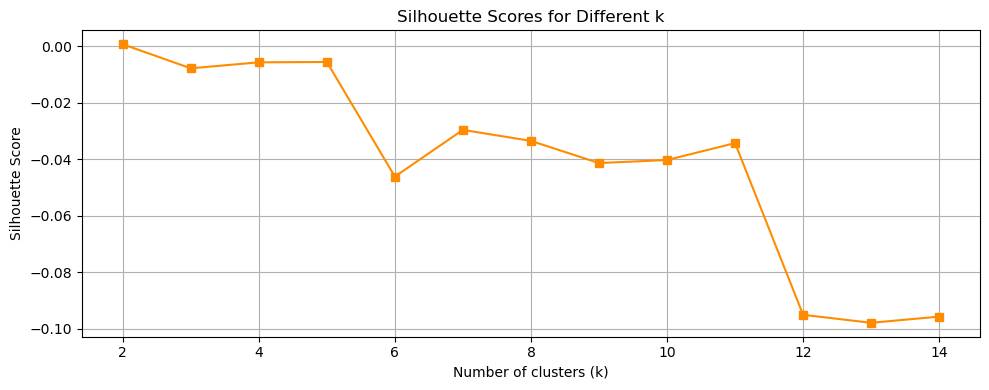

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


### Cluster Visualization for k = 2

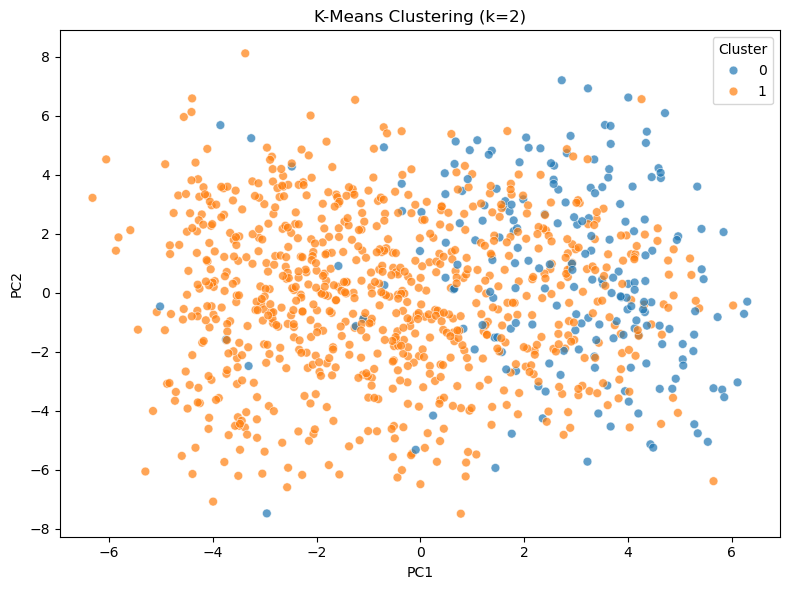

### Cluster Centers in PCA Space

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC914,PC915,PC916,PC917,PC918,PC919,PC920,PC921,PC922,PC923
0,2.767017,0.645175,0.233329,0.029539,0.208873,-1.107150,-0.170319,0.292301,0.005290,0.145328,...,0.030374,0.059200,-0.082740,-0.044125,-0.029194,0.093153,-0.067513,0.097659,-0.036326,-0.006656
1,-0.704773,-0.164329,-0.059430,-0.007524,-0.053201,0.281997,0.043381,-0.074451,-0.001347,-0.037016,...,-0.007736,-0.015078,0.021074,0.011239,0.007436,-0.023727,0.017196,-0.024874,0.009252,0.001695


✅ Clustered data saved to ../data/processed/pca_kmeans_labeled.csv


In [3]:
# Step 4A: K-Means Clustering

from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# --- Load PCA-reduced data ---
display(Markdown("## Step 4A: K-Means Clustering"))
df_pca = pd.read_csv("../data/processed/pca_reduced_data.csv")

# --- Determine optimal k using Elbow Method and Silhouette Scores ---
k_range = range(2, 15)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_pca, kmeans.labels_))

# Plot Elbow Method
plt.figure(figsize=(10, 4))
plt.plot(k_range, inertias, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Silhouette Scores
plt.figure(figsize=(10, 4))
plt.plot(k_range, silhouette_scores, marker='s', color='darkorange')
plt.title('Silhouette Scores for Different k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Choose optimal k and fit final model ---
optimal_k = silhouette_scores.index(max(silhouette_scores)) + 2
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = final_kmeans.fit_predict(df_pca)
df_pca["cluster"] = clusters

# --- Visualize Clusters (in 2D PCA space) ---
display(Markdown(f"### Cluster Visualization for k = {optimal_k}"))
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=df_pca["PC1"],
    y=df_pca["PC2"],
    hue=df_pca["cluster"],
    palette="tab10",
    alpha=0.7,
    s=40
)
plt.title(f"K-Means Clustering (k={optimal_k})")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# --- Interpret Cluster Centers ---
display(Markdown("### Cluster Centers in PCA Space"))
centers = pd.DataFrame(final_kmeans.cluster_centers_, columns=df_pca.columns[:-1])
display(centers)

# Save labeled dataset
df_pca.to_csv("../data/processed/pca_kmeans_labeled.csv", index=False)
print("✅ Clustered data saved to ../data/processed/pca_kmeans_labeled.csv")


### Dendrogram - Linkage: `ward`

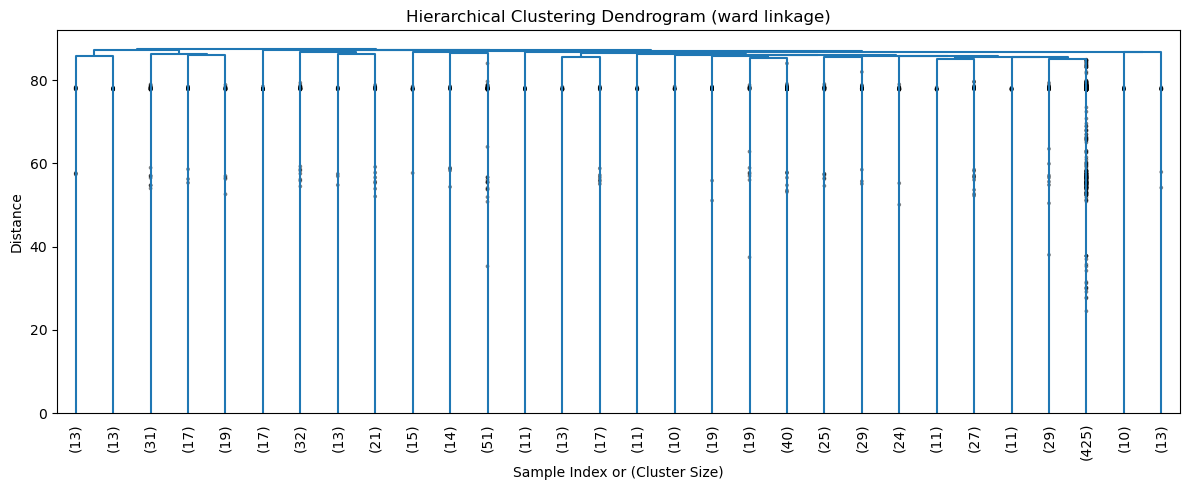

### Dendrogram - Linkage: `complete`

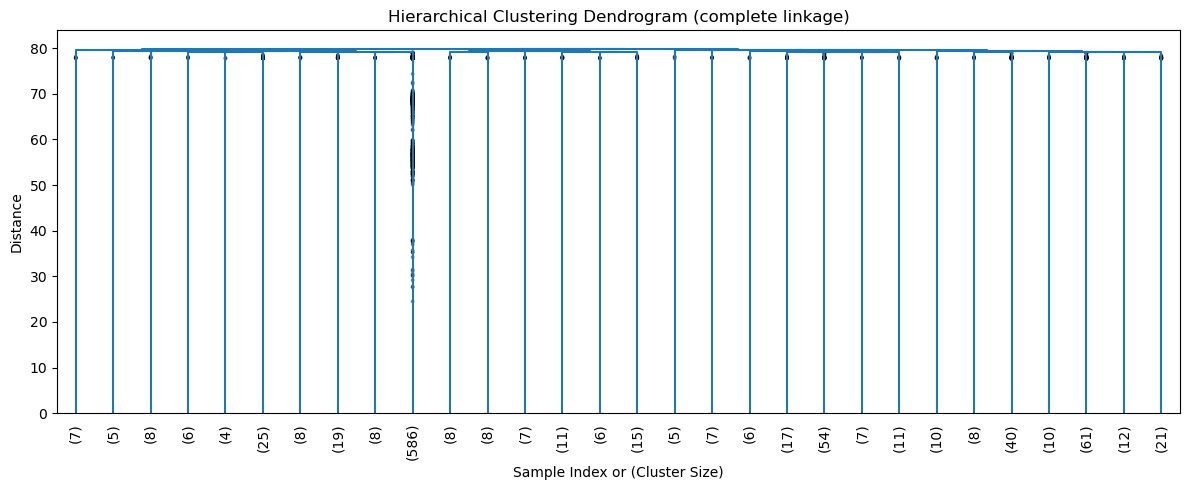

### Dendrogram - Linkage: `average`

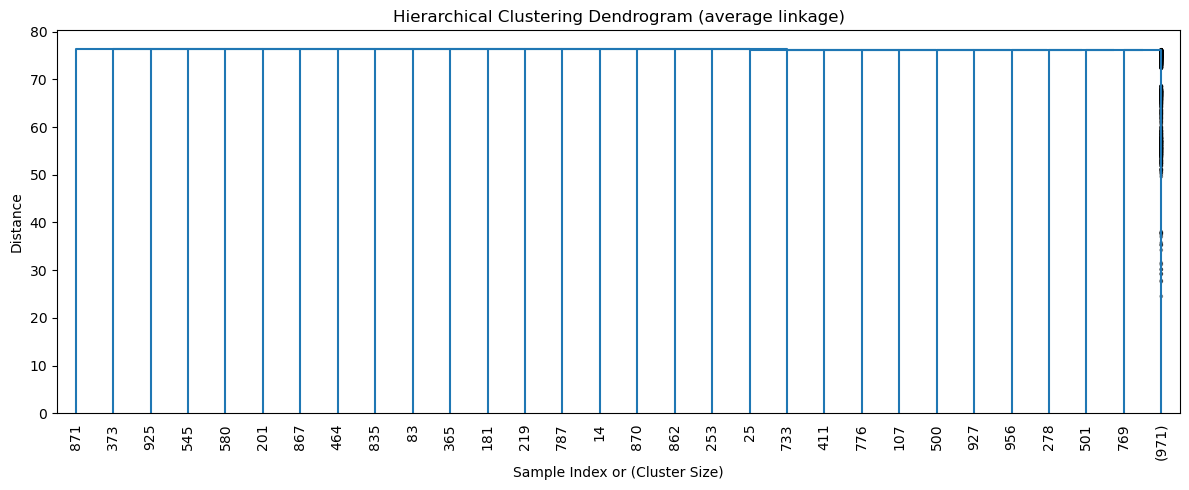

### Dendrogram - Linkage: `single`

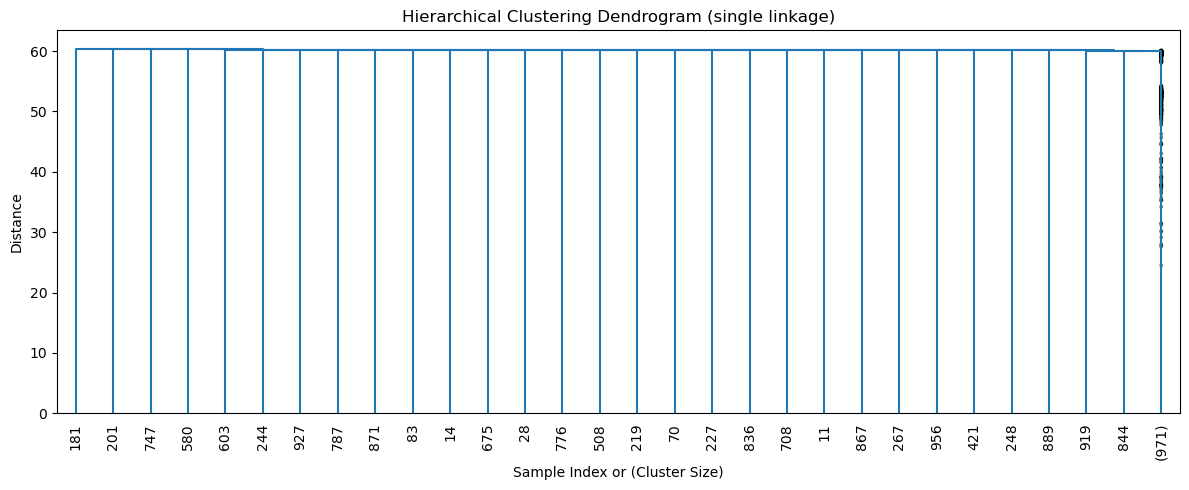

### Cluster Visualization: Hierarchical Clustering with `ward` linkage (k=2)

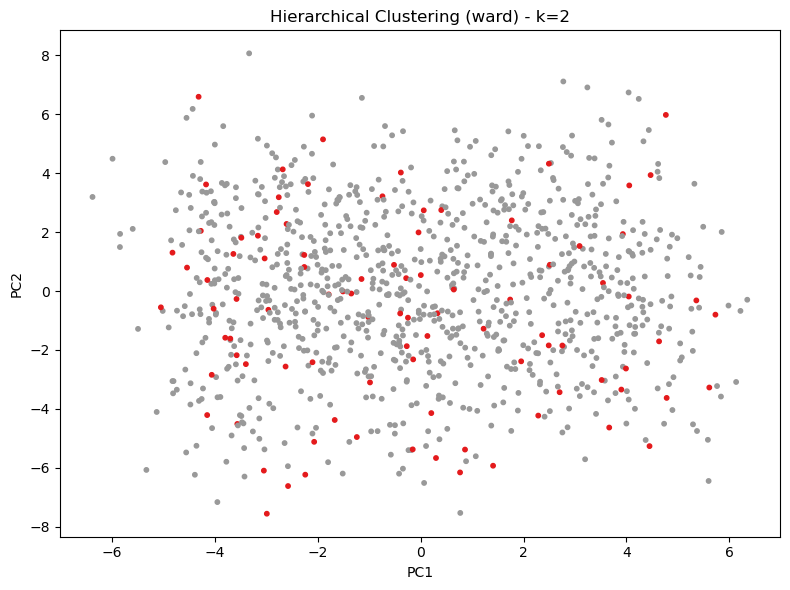


### 📊 Notes:
- Dendrograms help us visually choose `k` based on large vertical jumps.
- Ward linkage is most common as it minimizes variance within clusters.
- Hierarchical results may differ from KMeans, especially in non-spherical data.


In [5]:
# Step 4B: Hierarchical Clustering

from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler

# --- Load PCA-reduced data (same as used in Step 4A) ---
df_pca = pd.read_csv("../data/processed/pca_reduced_data.csv")

# --- Linkage Methods to Try ---
linkage_methods = ['ward', 'complete', 'average', 'single']

for method in linkage_methods:
    display(Markdown(f"### Dendrogram - Linkage: `{method}`"))
    linked = linkage(df_pca, method=method)

    plt.figure(figsize=(12, 5))
    dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=10., show_contracted=True)
    plt.title(f"Hierarchical Clustering Dendrogram ({method} linkage)")
    plt.xlabel("Sample Index or (Cluster Size)")
    plt.ylabel("Distance")
    plt.tight_layout()
    plt.show()

# --- Choose preferred method (e.g., 'ward') and cut dendrogram ---

chosen_method = 'ward'
linked = linkage(df_pca, method=chosen_method)
k_hier = 2  # Use 2 for comparison with KMeans
labels_hier = fcluster(linked, k_hier, criterion='maxclust')

# --- Visualize cluster assignment on PCA (2D) projection ---
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2).fit_transform(df_pca)

display(Markdown(f"### Cluster Visualization: Hierarchical Clustering with `{chosen_method}` linkage (k={k_hier})"))
plt.figure(figsize=(8, 6))
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=labels_hier, cmap='Set1', s=10)
plt.title(f"Hierarchical Clustering ({chosen_method}) - k={k_hier}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# --- Compare with KMeans if needed (reuse labels_kmeans from Step 4A) ---
display(Markdown("""
### 📊 Notes:
- Dendrograms help us visually choose `k` based on large vertical jumps.
- Ward linkage is most common as it minimizes variance within clusters.
- Hierarchical results may differ from KMeans, especially in non-spherical data.
"""))


## 🔍 Optimizing DBSCAN Parameters

**Best DBSCAN Parameters:** `eps=0.5`, `min_samples=5` with silhouette = -1.0000

## DBSCAN Clustering (Optimized)

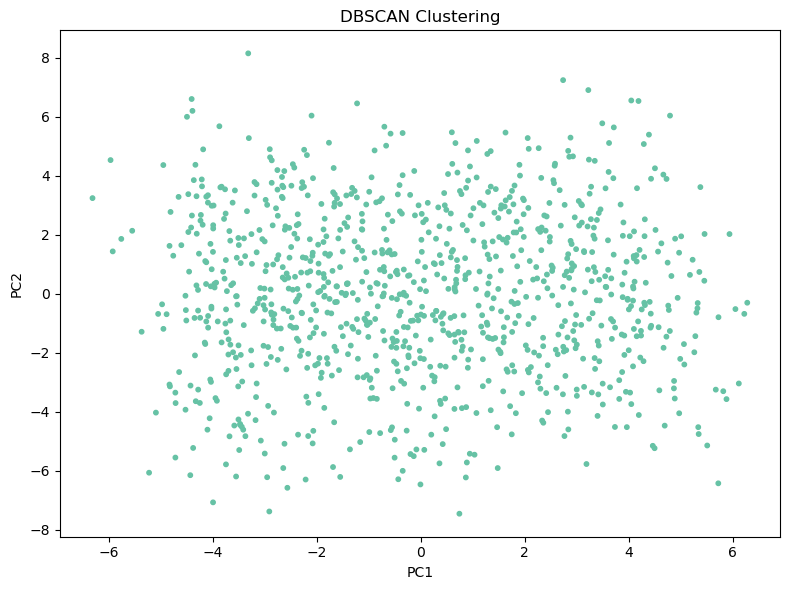

**DBSCAN Result:** 0 clusters (silhouette = N/A)

## Gaussian Mixture Model (GMM)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


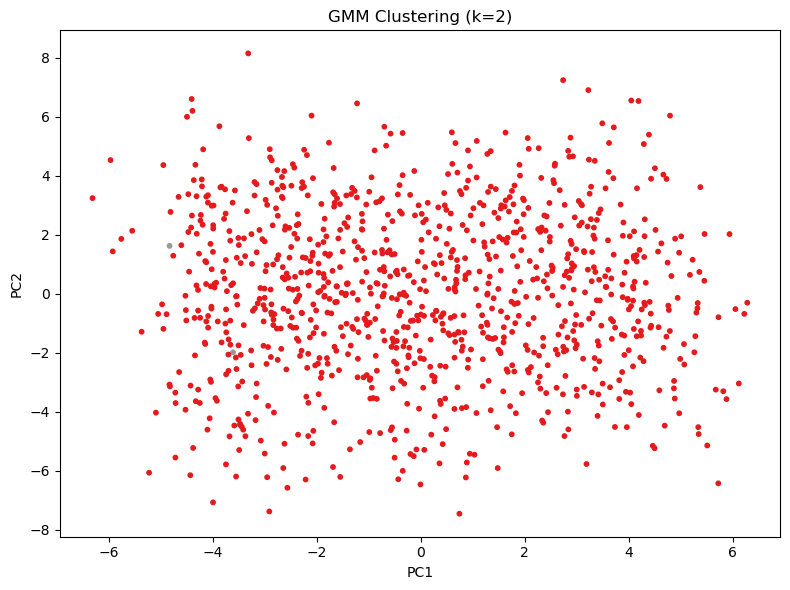

**GMM Result:** Silhouette Score = -0.0973


### 📌 Clustering Method Comparison Summary
- **DBSCAN** is good for discovering clusters of varying shapes but sensitive to `eps` and `min_samples`.
- **GMM** allows soft assignment (probabilistic) and can model elliptical clusters.
- These methods complement KMeans and Hierarchical by capturing different clustering assumptions.


In [8]:
# Step 4C: DBSCAN & Gaussian Mixture Models (GMM)

from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load PCA-reduced data
pca_df = pd.read_csv("../data/processed/pca_reduced_data.csv")

# Reduce to 2D for visualization
pca_2d = PCA(n_components=2).fit_transform(pca_df)

# --- Optimize DBSCAN Parameters ---
display(Markdown("## 🔍 Optimizing DBSCAN Parameters"))
best_score = -1
best_params = (0.5, 5)  # Fallback defaults
best_labels = None

for eps in [0.3, 0.5, 0.7, 0.9, 1.1]:
    for min_samples in [5, 10, 15]:
        try:
            model = DBSCAN(eps=eps, min_samples=min_samples)
            labels = model.fit_predict(pca_df)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters > 1 and len(set(labels)) < len(pca_df):
                score = silhouette_score(pca_df, labels)
                if score > best_score:
                    best_score = score
                    best_params = (eps, min_samples)
                    best_labels = labels
        except Exception as e:
            continue

optimal_eps, optimal_min_samples = best_params

display(Markdown(f"**Best DBSCAN Parameters:** `eps={optimal_eps}`, `min_samples={optimal_min_samples}` with silhouette = {best_score:.4f}"))

# --- DBSCAN with Optimal Parameters ---
display(Markdown("## DBSCAN Clustering (Optimized)"))
dbscan = DBSCAN(eps=optimal_eps, min_samples=optimal_min_samples)
dbscan_labels = dbscan.fit_predict(pca_df)

plt.figure(figsize=(8, 6))
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=dbscan_labels, cmap='Set2', s=10)
plt.title("DBSCAN Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
if n_clusters_dbscan > 1:
    sil_score_dbscan = silhouette_score(pca_df, dbscan_labels)
else:
    sil_score_dbscan = "N/A"

display(Markdown(f"**DBSCAN Result:** {n_clusters_dbscan} clusters (silhouette = {sil_score_dbscan})"))

# --- Gaussian Mixture Models (GMM) ---
display(Markdown("## Gaussian Mixture Model (GMM)"))
k_gmm = 2  # same as KMeans and hierarchical for comparison
gmm = GaussianMixture(n_components=k_gmm, random_state=42)
gmm_labels = gmm.fit_predict(pca_df)

plt.figure(figsize=(8, 6))
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=gmm_labels, cmap='Set1', s=10)
plt.title(f"GMM Clustering (k={k_gmm})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

sil_score_gmm = silhouette_score(pca_df, gmm_labels)
display(Markdown(f"**GMM Result:** Silhouette Score = {sil_score_gmm:.4f}"))

# --- Commentary ---
display(Markdown("""
### 📌 Clustering Method Comparison Summary
- **DBSCAN** is good for discovering clusters of varying shapes but sensitive to `eps` and `min_samples`.
- **GMM** allows soft assignment (probabilistic) and can model elliptical clusters.
- These methods complement KMeans and Hierarchical by capturing different clustering assumptions.
"""))
